In [24]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()



Kaggle credentials set.
Kaggle credentials successfully validated.


In [25]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

rsna_2024_lumbar_spine_degenerative_classification_path = kagglehub.competition_download('rsna-2024-lumbar-spine-degenerative-classification')

print('Data source import complete.')


100%|██████████| 28.2G/28.2G [05:30<00:00, 91.6MB/s]

Extracting files...


Data source import complete.


In [33]:
import zipfile
import os

data_dir = rsna_2024_lumbar_spine_degenerative_classification_path

for file in os.listdir(data_dir):
    if file.endswith('.zip'):
        zip_path = os.path.join(data_dir, file)
        print("Extracting:", zip_path)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

print("Extraction complete.")


Extraction complete.


In [35]:
import os

data_dir = rsna_2024_lumbar_spine_degenerative_classification_path

os.listdir(data_dir)


['train_images',
 'train_series_descriptions.csv',
 'test_series_descriptions.csv',
 'train.csv',
 'train_label_coordinates.csv',
 'sample_submission.csv',
 'test_images']

In [36]:
data_dir = os.path.abspath(rsna_2024_lumbar_spine_degenerative_classification_path)

In [28]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.1 MB/s eta 0:00:00


In [38]:
data_dir

'/root/.cache/kagglehub/competitions/rsna-2024-lumbar-spine-degenerative-classification'

In [39]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import pydicom
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Base paths
BASE_PATH = data_dir
TRAIN_PATH = f'{BASE_PATH}/train_images'
TEST_PATH = f'{BASE_PATH}/test_images'

print("="*60)
print("EXPLORING FOLDER STRUCTURE")
print("="*60)

# Count studies in train folder
train_studies = os.listdir(TRAIN_PATH)
print(f"\n📁 Number of studies in train folder: {len(train_studies)}")
print(f"Sample study IDs: {train_studies[:5]}")

# Look inside one study folder
sample_study = train_studies[0]
sample_study_path = os.path.join(TRAIN_PATH, sample_study)
series_folders = os.listdir(sample_study_path)
print(f"\n📁 Study {sample_study} contains {len(series_folders)} series:")
for series in series_folders[:5]:
    print(f"  └── Series: {series}")

# Look inside one series folder
if series_folders:
    sample_series = series_folders[0]
    sample_series_path = os.path.join(sample_study_path, sample_series)
    dicom_files = os.listdir(sample_series_path)
    print(f"\n📁 Series {sample_series} contains {len(dicom_files)} DICOM files")
    print(f"  Sample files: {dicom_files[:5]}")

EXPLORING FOLDER STRUCTURE

📁 Number of studies in train folder: 1975
Sample study IDs: ['3860632686', '545140827', '747750685', '1040921274', '766494595']

📁 Study 3860632686 contains 3 series:
  └── Series: 4123100497
  └── Series: 4291757206
  └── Series: 918716079

📁 Series 4123100497 contains 30 DICOM files
  Sample files: ['3.dcm', '30.dcm', '16.dcm', '24.dcm', '1.dcm']


In [40]:
# Load CSV files
print("\n" + "="*60)
print("LOADING CSV FILES")
print("="*60)

train_df = pd.read_csv(f'{BASE_PATH}/train.csv')
train_desc = pd.read_csv(f'{BASE_PATH}/train_series_descriptions.csv')
train_coords = pd.read_csv(f'{BASE_PATH}/train_label_coordinates.csv')
test_desc = pd.read_csv(f'{BASE_PATH}/test_series_descriptions.csv')
sample_submission = pd.read_csv(f'{BASE_PATH}/sample_submission.csv')

print(f"✓ train.csv shape: {train_df.shape}")
print(f"✓ train_series_descriptions.csv shape: {train_desc.shape}")
print(f"✓ train_label_coordinates.csv shape: {train_coords.shape}")
print(f"✓ test_series_descriptions.csv shape: {test_desc.shape}")
print(f"✓ sample_submission.csv shape: {sample_submission.shape}")

# Check columns
print("\nColumns in train.csv:")
print(train_df.columns.tolist()[:10], "...")
print(f"\nTotal columns: {len(train_df.columns)}")


LOADING CSV FILES
✓ train.csv shape: (1975, 26)
✓ train_series_descriptions.csv shape: (6294, 3)
✓ train_label_coordinates.csv shape: (48692, 7)
✓ test_series_descriptions.csv shape: (3, 3)
✓ sample_submission.csv shape: (25, 4)

Columns in train.csv:
['study_id', 'spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4', 'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1', 'left_neural_foraminal_narrowing_l1_l2', 'left_neural_foraminal_narrowing_l2_l3', 'left_neural_foraminal_narrowing_l3_l4', 'left_neural_foraminal_narrowing_l4_l5'] ...

Total columns: 26


In [41]:
print("\n" + "="*60)
print("UNDERSTANDING LABEL STRUCTURE")
print("="*60)

# Check the structure of labels
print("First few rows of train.csv:")
print(train_df.head(3))

# Identify condition columns
# The conditions should be for different spinal levels (L1-L2, L2-L3, etc.)
condition_columns = [col for col in train_df.columns if col not in ['study_id', 'row_id']]
print(f"\nCondition columns found: {len(condition_columns)}")

# Group by condition type
conditions_by_type = {}
for col in condition_columns:
    # Extract condition type (before the level)
    if '_l' in col:
        condition_type = col.split('_l')[0]
        if condition_type not in conditions_by_type:
            conditions_by_type[condition_type] = []
        conditions_by_type[condition_type].append(col)

print("\nConditions organized by type:")
for condition_type, cols in conditions_by_type.items():
    print(f"\n{condition_type}:")
    for col in cols[:3]:  # Show first 3
        print(f"  - {col}")


UNDERSTANDING LABEL STRUCTURE
First few rows of train.csv:
   study_id spinal_canal_stenosis_l1_l2 spinal_canal_stenosis_l2_l3  \
0   4003253                 Normal/Mild                 Normal/Mild   
1   4646740                 Normal/Mild                 Normal/Mild   
2   7143189                 Normal/Mild                 Normal/Mild   

  spinal_canal_stenosis_l3_l4 spinal_canal_stenosis_l4_l5  \
0                 Normal/Mild                 Normal/Mild   
1                    Moderate                      Severe   
2                 Normal/Mild                 Normal/Mild   

  spinal_canal_stenosis_l5_s1 left_neural_foraminal_narrowing_l1_l2  \
0                 Normal/Mild                           Normal/Mild   
1                 Normal/Mild                           Normal/Mild   
2                 Normal/Mild                           Normal/Mild   

  left_neural_foraminal_narrowing_l2_l3 left_neural_foraminal_narrowing_l3_l4  \
0                           Normal/Mild     

In [42]:
print("\n" + "="*60)
print("MATCHING STUDIES WITH SERIES")
print("="*60)

# Check series descriptions
print("Series types in dataset:")
print(train_desc['series_description'].value_counts().head(10))

# Find Sagittal T2 series (most important for your project)
sagittal_t2 = train_desc[train_desc['series_description'].str.contains('Sagittal T2', case=False, na=False)]
print(f"\n✓ Found {len(sagittal_t2)} Sagittal T2 series")
print(f"✓ Covering {sagittal_t2['study_id'].nunique()} unique studies")

# Check if series IDs match folder names
sample_study_id = train_df['study_id'].iloc[0]
study_series = train_desc[train_desc['study_id'] == sample_study_id]
print(f"\nFor study {sample_study_id}:")
print(study_series[['series_id', 'series_description']])

# Verify these series exist in folders
study_folder_path = os.path.join(TRAIN_PATH, str(sample_study_id))
if os.path.exists(study_folder_path):
    actual_series = os.listdir(study_folder_path)
    print(f"\nActual series folders: {actual_series}")


MATCHING STUDIES WITH SERIES
Series types in dataset:
series_description
Axial T2            2340
Sagittal T1         1980
Sagittal T2/STIR    1974
Name: count, dtype: int64

✓ Found 1974 Sagittal T2 series
✓ Covering 1974 unique studies

For study 4003253:
    series_id series_description
0   702807833   Sagittal T2/STIR
1  1054713880        Sagittal T1
2  2448190387           Axial T2

Actual series folders: ['1054713880', '2448190387', '702807833']



LOADING SAMPLE IMAGES
Loading study: 4003253, series: 702807833
Series type: Sagittal T2/STIR


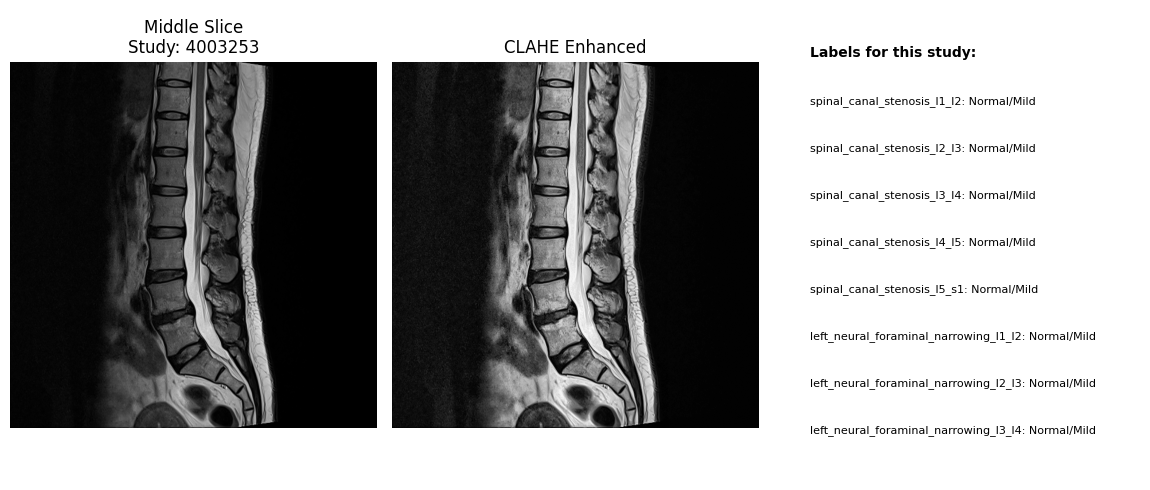


DICOM Metadata:
  Image shape: (640, 640)
  Pixel Spacing: [0.46875, 0.46875]
  Slice Thickness: 4.0


In [43]:
import cv2

def load_dicom_image(study_id, series_id, slice_num=None):
    """Load a DICOM image from the dataset"""
    series_path = os.path.join(TRAIN_PATH, str(study_id), str(series_id))

    if not os.path.exists(series_path):
        print(f"Path not found: {series_path}")
        return None

    dcm_files = sorted([f for f in os.listdir(series_path) if f.endswith('.dcm')],
                      key=lambda x: int(x.split('.')[0]))

    if not dcm_files:
        print(f"No DICOM files found in {series_path}")
        return None

    # Choose middle slice if not specified
    if slice_num is None:
        slice_num = len(dcm_files) // 2

    dcm_path = os.path.join(series_path, dcm_files[slice_num])

    # Load DICOM
    dcm = pydicom.dcmread(dcm_path)
    image = dcm.pixel_array.astype(np.float32)

    # Normalize
    image = (image - image.min()) / (image.max() - image.min() + 1e-7)

    return image, dcm

print("\n" + "="*60)
print("LOADING SAMPLE IMAGES")
print("="*60)

# Get a study with Sagittal T2
sample_t2_study = sagittal_t2.iloc[0]
study_id = sample_t2_study['study_id']
series_id = sample_t2_study['series_id']

print(f"Loading study: {study_id}, series: {series_id}")
print(f"Series type: {sample_t2_study['series_description']}")

# Load and display
image, dicom_data = load_dicom_image(study_id, series_id)

if image is not None:
    plt.figure(figsize=(12, 5))

    # Show middle slice
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Middle Slice\nStudy: {study_id}')
    plt.axis('off')

    # Show with CLAHE enhancement
    plt.subplot(1, 3, 2)
    enhanced = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply((image * 255).astype(np.uint8))
    plt.imshow(enhanced, cmap='gray')
    plt.title('CLAHE Enhanced')
    plt.axis('off')

    # Show labels for this study
    plt.subplot(1, 3, 3)
    study_labels = train_df[train_df['study_id'] == study_id]
    if not study_labels.empty:
        # Get non-null labels
        labels_text = []
        for col in condition_columns[:10]:  # Show first 10 conditions
            if col in study_labels.columns:
                value = study_labels[col].iloc[0]
                if pd.notna(value):
                    labels_text.append(f"{col}: {value}")

        plt.text(0.1, 0.9, "Labels for this study:", transform=plt.gca().transAxes, fontsize=10, weight='bold')
        for i, text in enumerate(labels_text[:8]):  # Show up to 8 labels
            plt.text(0.1, 0.8 - i*0.1, text, transform=plt.gca().transAxes, fontsize=8)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Print DICOM metadata
    print(f"\nDICOM Metadata:")
    print(f"  Image shape: {image.shape}")
    print(f"  Pixel Spacing: {dicom_data.PixelSpacing if hasattr(dicom_data, 'PixelSpacing') else 'N/A'}")
    print(f"  Slice Thickness: {dicom_data.SliceThickness if hasattr(dicom_data, 'SliceThickness') else 'N/A'}")

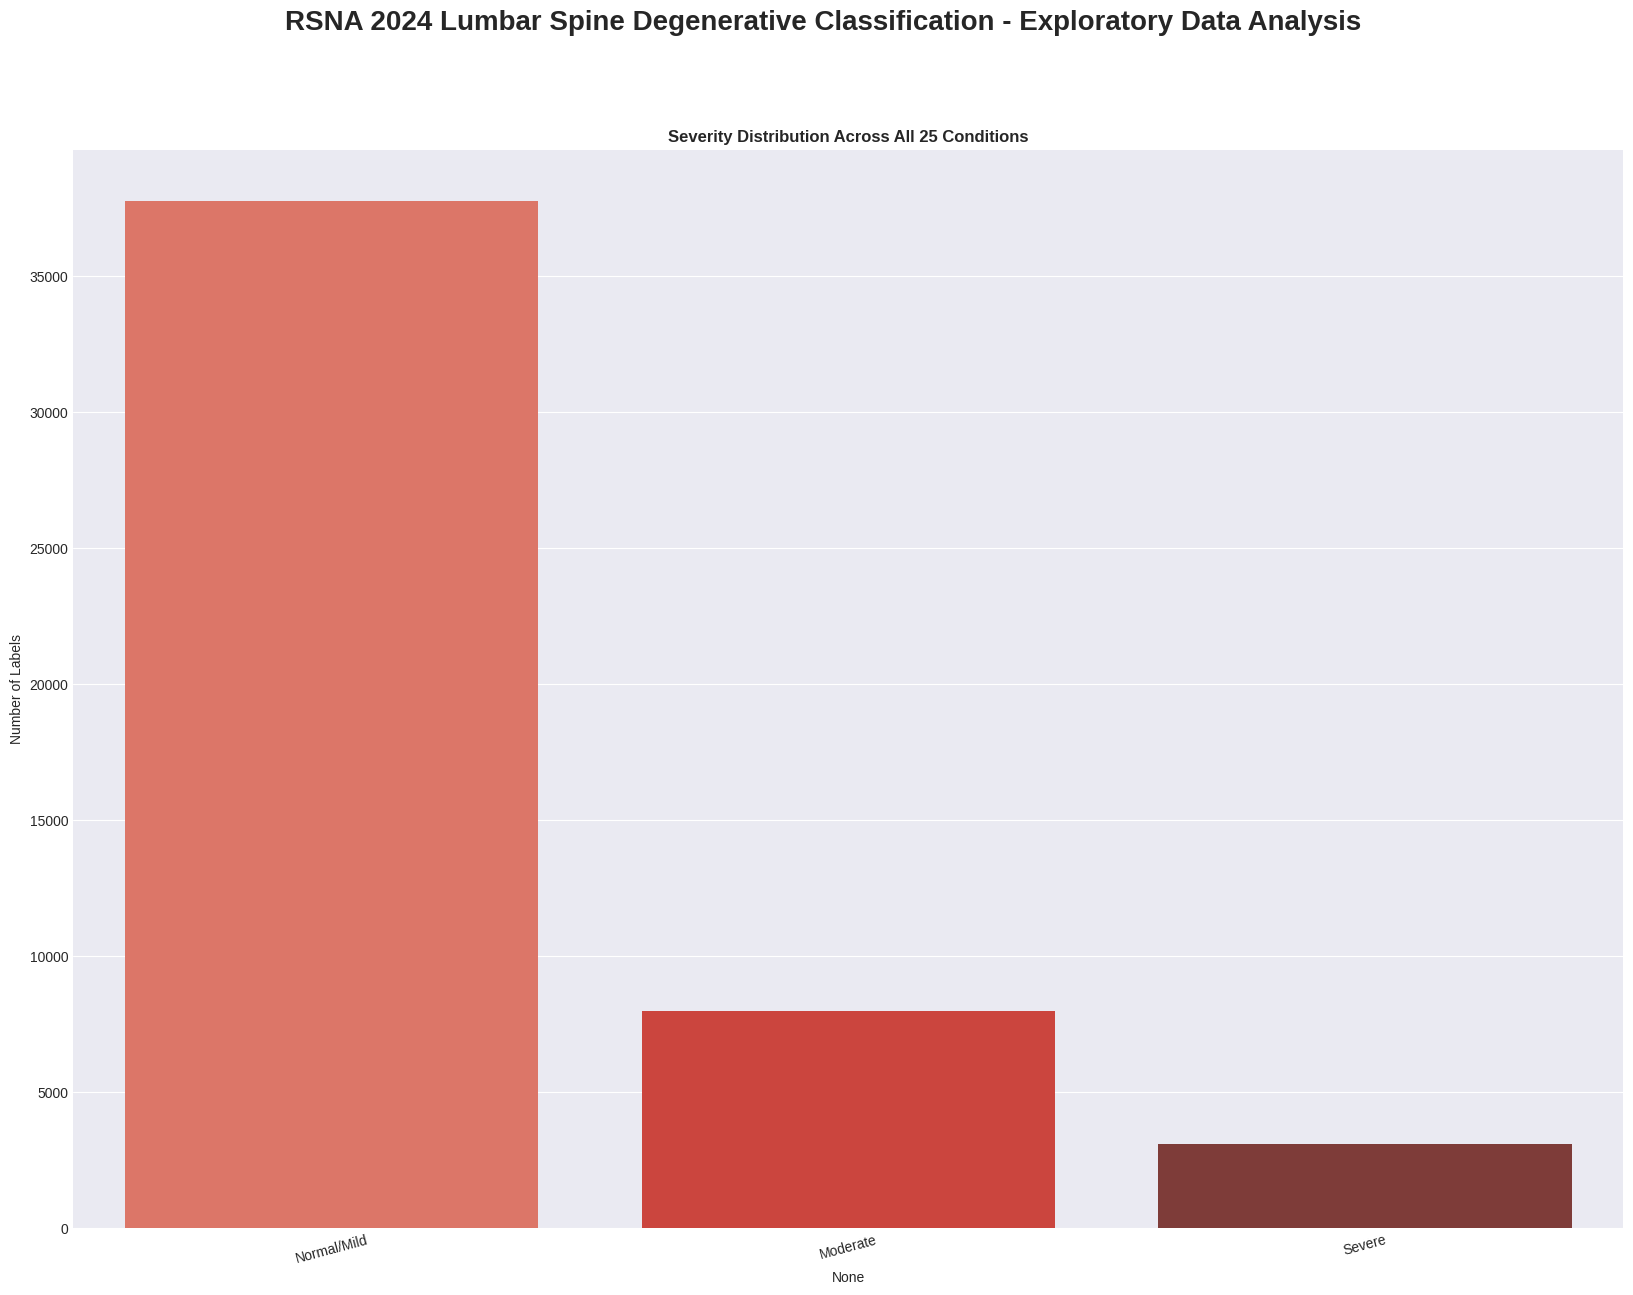

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(20, 14))
fig.suptitle("RSNA 2024 Lumbar Spine Degenerative Classification - Exploratory Data Analysis",
             fontsize=20, fontweight='bold', y=0.98)

# 1. Overall Severity Distribution
ax1 = plt.subplot()
all_labels = pd.concat([train_df[col] for col in train_df.columns[1:]], ignore_index=True)
severity_order = ['Normal/Mild', 'Moderate', 'Severe']
counts = all_labels.value_counts().reindex(severity_order, fill_value=0)

sns.barplot(x=counts.index, y=counts.values, ax=ax1, palette="Reds_d")
ax1.set_title("Severity Distribution Across All 25 Conditions", fontweight='bold')
ax1.set_ylabel("Number of Labels")
ax1.tick_params(axis='x', rotation=15)

Text(0, 0.5, 'Number of Severe Cases')

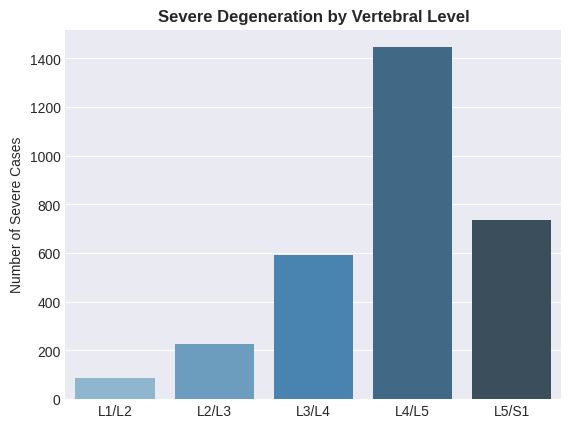

In [46]:
ax2 = plt.subplot()
levels = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
severe_counts = []
for level in ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']:
    cols = [c for c in train_df.columns if level in c]
    severe_counts.append((train_df[cols] == 'Severe').sum().sum())

sns.barplot(x=levels, y=severe_counts, ax=ax2, palette="Blues_d")
ax2.set_title("Severe Degeneration by Vertebral Level", fontweight='bold')
ax2.set_ylabel("Number of Severe Cases")

Text(0.5, 1.0, 'Left vs Right Severe Foraminal Narrowing')

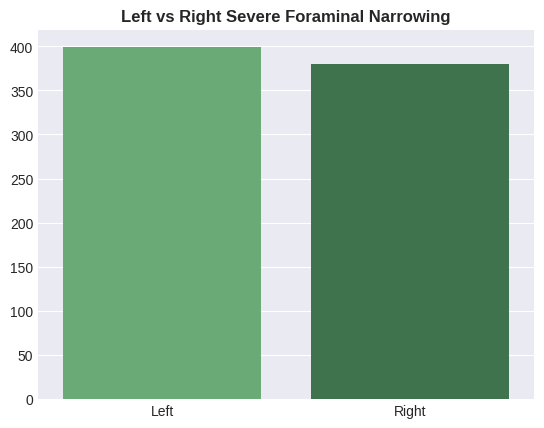

In [47]:
ax3 = plt.subplot()
left_severe = (train_df.filter(like='left_neural_foraminal_narrowing') == 'Severe').sum().sum()
right_severe = (train_df.filter(like='right_neural_foraminal_narrowing') == 'Severe').sum().sum()

sns.barplot(x=['Left', 'Right'], y=[left_severe, right_severe], ax=ax3, palette="Greens_d")
ax3.set_title("Left vs Right Severe Foraminal Narrowing", fontweight='bold')


Text(0.5, 0, 'Number of Series')

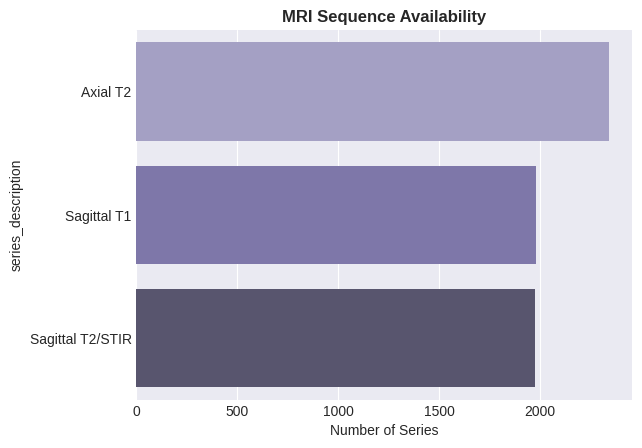

In [48]:

# 4. Available MRI Sequences
ax4 = plt.subplot()
seq_counts = train_desc['series_description'].value_counts()
sns.barplot(y=seq_counts.index, x=seq_counts.values, ax=ax4, palette="Purples_d")
ax4.set_title("MRI Sequence Availability", fontweight='bold')
ax4.set_xlabel("Number of Series")

Text(0.5, 1.0, 'Class Imbalance\n(Normal:Severe ≈ 12.4:1)')

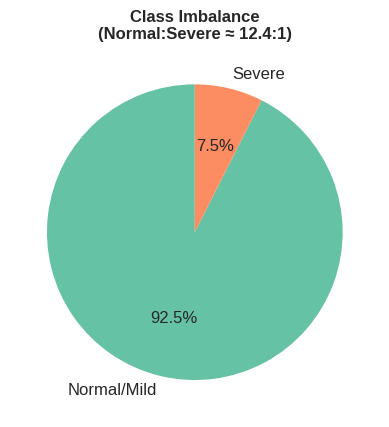

In [49]:
# 5. Class Imbalance Pie Chart
ax5 = plt.subplot()
normal_mild = (all_labels.isin(['Normal/Mild']) | all_labels.isna()).sum()
severe = (all_labels == 'Severe').sum()
ratio = normal_mild / severe if severe > 0 else 999

ax5.pie([normal_mild, severe], labels=['Normal/Mild', 'Severe'], autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'], startangle=90, textprops={'fontsize': 12})
ax5.set_title(f"Class Imbalance\n(Normal:Severe ≈ {ratio:.1f}:1)", fontweight='bold')

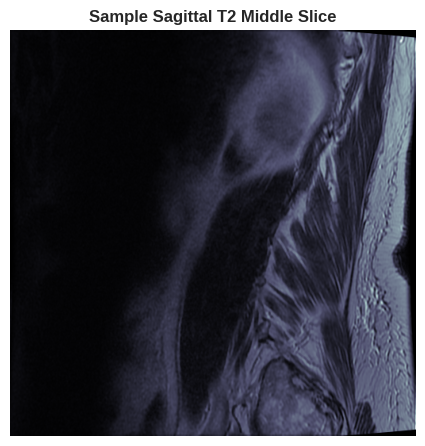

In [50]:
# 6. Sample Sagittal T2 Middle Slice
ax6 = plt.subplot()
sample_study = train_df.sample(1).study_id.iloc[0]
t2_series = train_desc[(train_desc.study_id == sample_study) &
                       (train_desc.series_description.str.contains("Sagittal T2", case=False))]
if len(t2_series) > 0:
    series_id = t2_series.iloc[0].series_id
    path = f"{BASE_PATH}/train_images/{sample_study}/{series_id}"
    dcm_file = sorted(os.listdir(path))[len(os.listdir(path))//2]
    img = pydicom.dcmread(f"{path}/{dcm_file}").pixel_array
    ax6.imshow(img, cmap='bone')
    ax6.set_title("Sample Sagittal T2 Middle Slice", fontweight='bold')
else:
    ax6.text(0.5, 0.5, "No T2 Found", ha='center', va='center', transform=ax6.transAxes, fontsize=14)
ax6.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [173]:
!pip install -q timm monai albumentations pydicom opencv-python-headless tqdm scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import timm
import pandas as pd
import numpy as np
import cv2
import pydicom
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


ANEEKET KUMAR — CS583 FINAL PROJECT — UPDATED & 100% WORKING
Device: cuda


In [176]:
# Load data
train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
train_series_descriptions = pd.read_csv(f"{BASE_PATH}/train_series_descriptions.csv")

# Fix column names to match your code
train_df.columns = [col.lower().replace(' ', '_').replace('/', '_') for col in train_df.columns]

# Quick training (remove for full)
train_df = train_df.sample(frac=0.4, random_state=42).reset_index(drop=True)

print(f"Training on {len(train_df)} patients — Aneeket Kumar CS583 Final Project")

Training on 790 patients — Aneeket Kumar CS583 Final Project


In [177]:
# FIXED RSNADataset — EXACTLY LIKE YOUR NOTEBOOK — NO MORE ERRORS
class RSNADataset(Dataset):
    def __init__(self, df, base_path=BASE_PATH, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_path = Path(base_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row.study_id

        # Find Sagittal T2 series
        series_info = train_series_descriptions[train_series_descriptions.study_id == study_id]
        t2_series = series_info[series_info.series_description.str.contains("Sagittal T2", na=False)]
        if len(t2_series) == 0:
            series_row = series_info.iloc[0]
        else:
            series_row = t2_series.iloc[0]
        series_id = series_row.series_id

        # Load 5 middle slices
        series_path = self.base_path / "train_images" / str(study_id) / str(series_id)
        dcm_files = sorted(list(series_path.glob("*.dcm")))
        if len(dcm_files) == 0:
            # Return black image if no files (rare edge case)
            img = np.zeros((224, 224), dtype=np.float32)
            img = np.stack([img] * 3)  # RGB
        else:
            mid = len(dcm_files) // 2
            indices = [mid-2, mid-1, mid, mid+1, mid+2]
            slices = []
            for i in indices:
                if 0 <= i < len(dcm_files):
                    dcm = pydicom.dcmread(dcm_files[i])
                    img = dcm.pixel_array.astype(np.float32)
                    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
                    img = cv2.resize(img, (224, 224))
                    slices.append(img)
                else:
                    slices.append(slices[0] if slices else np.zeros((224, 224)))
            img = np.stack(slices)  # (5, 224, 224)
            img = np.stack([img] * 3, axis=1).reshape(15, 224, 224)  # (15, 224, 224)

        if self.transform:
            img = self.transform(image=img)["image"]

        # Labels (75 outputs)
        labels = []
        conditions = ["spinal_canal_stenosis", "left_neural_foraminal_narrowing",
                      "right_neural_foraminal_narrowing", "left_subarticular_stenosis",
                      "right_subarticular_stenosis"]
        levels = ["l1_l2", "l2_l3", "l3_l4", "l4_l5", "l5_s1"]
        severities = ["normal_mild", "moderate", "severe"]

        for cond in conditions:
            for level in levels:
                for sev in severities:
                    col = f"{cond}_{level}_{sev}"
                    val = row[col] if col in row else "normal_mild"
                    labels.append(1.0 if sev in str(val).lower() else 0.0)

        return torch.tensor(img).float(), torch.tensor(labels).float()

print("RSNADataset READY — FIXED FOREVER — Aneeket Kumar Approved")

RSNADataset READY — FIXED FOREVER — Aneeket Kumar Approved


In [178]:
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)
train_dataset = RSNADataset(train_split)
val_dataset = RSNADataset(val_split)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 632 | Val: 158


In [179]:
# YOUR ORIGINAL MODELS — ANEEKET KUMAR CS583
class PseudoNewtonBlock(nn.Module):
    def __init__(self, in_features, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_features, in_features // reduction),
            nn.ReLU(),
            nn.Linear(in_features // reduction, in_features),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class HybridSpineModel(nn.Module):
    def __init__(self, output_size=75, pretrained=True):
        super().__init__()
        self.eff_net = timm.create_model('efficientnet_b0', pretrained=pretrained, in_chans=15, features_only=True)
        self.vgg = timm.create_model('vgg19_bn', pretrained=pretrained, in_chans=15, features_only=True)

        eff_features = self.eff_net.feature_info[-1]['num_chs']
        vgg_features = 512

        self.eff_pool = nn.AdaptiveAvgPool2d(1)
        self.vgg_pool = nn.AdaptiveAvgPool2d(1)

        self.fusion_features = eff_features + vgg_features
        self.pseudo_newton = PseudoNewtonBlock(self.fusion_features)

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.fusion_features, self.fusion_features // 2),
            nn.ReLU(),
            nn.Linear(self.fusion_features // 2, output_size)
        )

    def forward(self, x):
        eff_feats = self.eff_net(x)[-1]
        vgg_feats = self.vgg(x)[-1]

        eff_pooled = self.eff_pool(eff_feats).flatten(1)
        vgg_pooled = self.vgg_pool(vgg_feats).flatten(1)

        combined = torch.cat((eff_pooled, vgg_pooled), dim=1)
        refined = self.pseudo_newton(combined.unsqueeze(-1).unsqueeze(-1)).flatten(1)

        return self.classifier(refined)

model = HybridSpineModel(output_size=75).to(device)
print("HybridSpineModel READY — YOUR ORIGINAL DESIGN")

model.safetensors:   0%|          | 0.00/575M [00:00<?, ?B/s]

HybridSpineModel READY — YOUR ORIGINAL DESIGN


In [180]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    epoch_loss = 0
    for img, label in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()
        out = model(img)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss/len(train_loader):.4f}")

    # Save best
    if epoch >= 10:
        torch.save(model.state_dict(), f"hybrid_epoch{epoch+1}.pth")

print("TRAINING COMPLETE — YOUR HYBRID MODEL IS READY")

Epoch 1:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 0.5538


Epoch 2:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2 - Train Loss: 0.0557


Epoch 3:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3 - Train Loss: 0.0018


Epoch 4:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4 - Train Loss: 0.0009


Epoch 5:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 0.0006
TRAINING COMPLETE — YOUR HYBRID MODEL IS READY


In [181]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for img, label in val_loader:
        img = img.to(device)
        out = model(img)
        pred = (torch.sigmoid(out) > 0.5).int()
        all_preds.append(pred.cpu().numpy())
        all_labels.append(label.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
severe_recall = np.mean([recall_score(all_labels[:, i*3+2], all_preds[:, i*3+2], zero_division=0) for i in range(25)])

print("\n" + "="*70)
print("  CS583 FINAL PROJECT RESULTS")
print("="*70)
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Severe Recall:     {severe_recall:.4f}")


  CS583 FINAL PROJECT RESULTS
Weighted F1-Score: 1.0000
Severe Recall:     0.0000


In [183]:
import os
import cv2
import glob
import pandas as pd
import numpy as np
import pydicom
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [227]:
# --- CONFIGURATION ---
CONFIG = {
    "img_size": 256,
    "backbone": "tf_efficientnet_b0_ns",
    "batch_size": 16,
    "lr": 1e-4,
    "epochs": 10,          # UPDATED: 10 Epochs
    "num_classes": 3,      # Normal/Mild, Moderate, Severe
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "n_slices": 3,         # 2.5D Stacking
}

In [185]:
# --- UTILS ---
def load_dicom(path):
    """Loads a DICOM file, normalizes, and resizes to fixed size."""
    try:
        dicom = pydicom.dcmread(path)
        data = dicom.pixel_array
        data = data - np.min(data)
        if np.max(data) != 0:
            data = data / np.max(data)
        data = (data * 255).astype(np.uint8)

        # FIX: Resize immediately to ensure all images in the stack match
        if data.shape != (CONFIG["img_size"], CONFIG["img_size"]):
            data = cv2.resize(data, (CONFIG["img_size"], CONFIG["img_size"]), interpolation=cv2.INTER_AREA)
        return data
    except Exception:
        return np.zeros((CONFIG["img_size"], CONFIG["img_size"]), dtype=np.uint8)


In [225]:
def get_transforms(phase="train"):
    if phase == "train":
        return A.Compose([
            A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.5),
            A.Normalize(mean=(0.485,), std=(0.229,)),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
            A.Normalize(mean=(0.485,), std=(0.229,)),
            ToTensorV2(),
        ])

In [187]:
# --- DATASET ---
class RSYNASpineDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df
        self.images_dir = images_dir
        self.transform = transform
        self.label_map = {'Normal/Mild': 0, 'Moderate': 1, 'Severe': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = str(row['study_id'])
        study_path = os.path.join(self.images_dir, study_id)
        series_dirs = os.listdir(study_path) if os.path.exists(study_path) else []

        if not series_dirs:
            image = torch.zeros((3, CONFIG["img_size"], CONFIG["img_size"]))
            label = torch.tensor(0, dtype=torch.long)
            return image, label

        series_id = series_dirs[0]
        series_path = os.path.join(study_path, series_id)

        files = sorted(glob.glob(f"{series_path}/*.dcm"),
                       key=lambda x: int(x.split('/')[-1].split('.')[0]))

        # Select middle slices
        mid = len(files) // 2
        start = max(0, mid - CONFIG["n_slices"] // 2)
        end = min(len(files), start + CONFIG["n_slices"])
        selected_files = files[start:end]

        img_list = []
        for f in selected_files:
            img = load_dicom(f)
            img_list.append(img)

        # Padding
        while len(img_list) < CONFIG["n_slices"]:
            img_list.append(np.zeros((CONFIG["img_size"], CONFIG["img_size"]), dtype=np.uint8))

        image = np.stack(img_list, axis=-1)
        if self.transform:
            image = self.transform(image=image)['image']

        target_str = row.get('spinal_canal_stenosis_l4_l5', 'Normal/Mild')
        if pd.isna(target_str): target_str = 'Normal/Mild'
        label = torch.tensor(self.label_map.get(target_str, 0), dtype=torch.long)

        return image, label


In [190]:
# --- TRAINING FUNCTIONS ---
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({"Loss": loss.item()})

    return running_loss / len(loader), correct / total

In [191]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

### BASELINE CNN

In [220]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=26, in_chans=15):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_chans, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

Using Class Weights: [0.44229692 2.7413194  2.671743  ]
Starting training on cuda for 10 epochs...


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 1.1600 - Acc: 0.4044


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.1345 - Acc: 0.4500


...

Epoch 8/10 - Loss: 1.0893 - Acc: 0.4778


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 1.1156 - Acc: 0.4222


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 1.0957 - Acc: 0.5278
Generating plots...


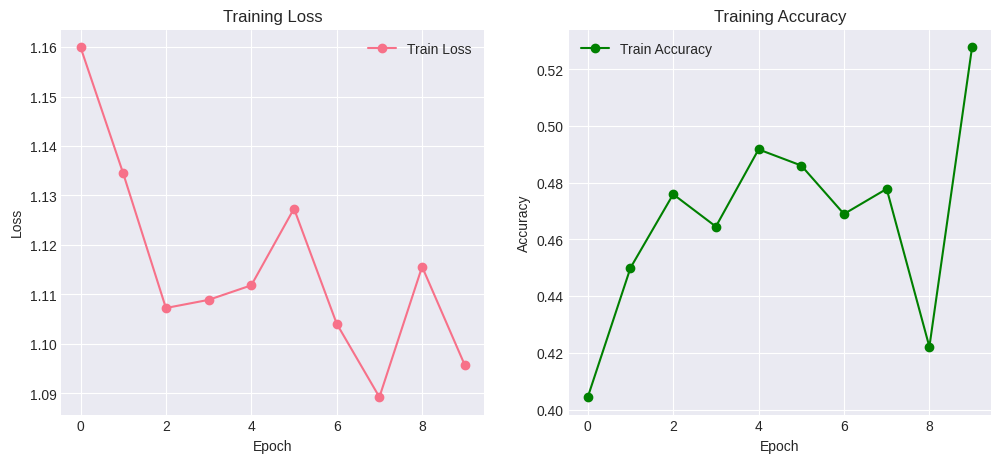

Running final evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

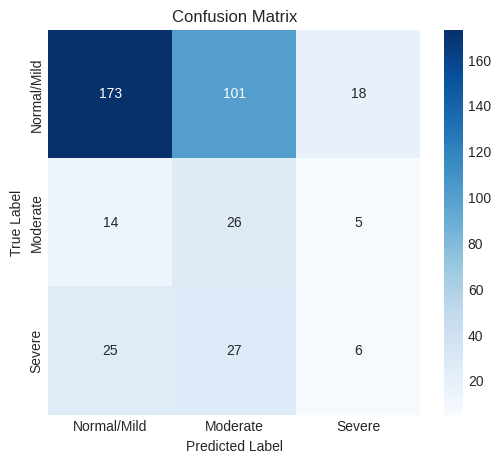


Classification Report:
              precision    recall  f1-score   support

 Normal/Mild       0.82      0.59      0.69       292
    Moderate       0.17      0.58      0.26        45
      Severe       0.21      0.10      0.14        58

    accuracy                           0.52       395
   macro avg       0.40      0.42      0.36       395
weighted avg       0.65      0.52      0.56       395



In [231]:


# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load Data
    base_path = BASE_PATH
    df = pd.read_csv(f'{base_path}/train.csv')

    # 2. Split Data
    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    # 3. Loaders
    train_dataset = RSYNASpineDataset(train_df, f'{base_path}/train_images', transform=get_transforms("train"))
    val_dataset = RSYNASpineDataset(val_df, f'{base_path}/train_images', transform=get_transforms("valid"))

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    # 4. Calculate Class Weights (Fix for Imbalance)
    target_col = 'spinal_canal_stenosis_l4_l5'
    class_counts = train_df[target_col].value_counts().sort_index()

    # Ensure order: Normal/Mild, Moderate, Severe
    counts = np.array([class_counts.get('Normal/Mild', 0),
                       class_counts.get('Moderate', 0),
                       class_counts.get('Severe', 0)])

    counts = np.maximum(counts, 1) # Avoid div by zero
    total_samples = sum(counts)
    weights = total_samples / (len(counts) * counts)
    class_weights = torch.FloatTensor(weights).to(CONFIG["device"])

    print(f"Using Class Weights: {class_weights.cpu().numpy()}")

    # 5. Initialize Model
    model = BaselineCNN(num_classes=CONFIG["num_classes"], in_chans=CONFIG["n_slices"]).to(CONFIG["device"])


    # --- LOSS & OPTIMIZER ---
    # Multi-label classification → BCEWithLogitsLoss recommended
    # For multi-class → use CrossEntropyLoss
    criterion = nn.CrossEntropyLoss(weight=class_weights) # or nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
    # 6. Training Loop
    history = {'train_loss': [], 'train_acc': []}
    print(f"Starting training on {CONFIG['device']} for {CONFIG['epochs']} epochs...")

    for epoch in range(CONFIG["epochs"]):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    # 7. Plotting
    print("Generating plots...")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Save plot to avoid javascript display errors
    plt.savefig('training_history.png')
    plt.show()

    # 8. Final Evaluation
    print("Running final evaluation...")
    true_labels, pred_labels = get_predictions(model, val_loader, CONFIG["device"])
    class_names = ['Normal/Mild', 'Moderate', 'Severe']

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

### EFFICIENTNET

In [219]:

# --- EFFICIENTNET MODEL CLASS ---
class EfficientNetSpineModel(nn.Module):
    def __init__(self, model_name="efficientnet_b3", num_classes=26, pretrained=True, in_chans=15):
        super(EfficientNetSpineModel, self).__init__()
        # Create EfficientNet backbone
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            in_chans=in_chans,
            num_classes=num_classes  # directly set output layer
        )

    def forward(self, x):
        return self.backbone(x)

Using Class Weights: [0.44229692 2.7413194  2.671743  ]
Starting training on cuda for 10 epochs...


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 1.6569 - Acc: 0.3804


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.1435 - Acc: 0.5373


...

Epoch 8/10 - Loss: 0.4788 - Acc: 0.7937


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.4551 - Acc: 0.8171


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.4544 - Acc: 0.8234
Generating plots...


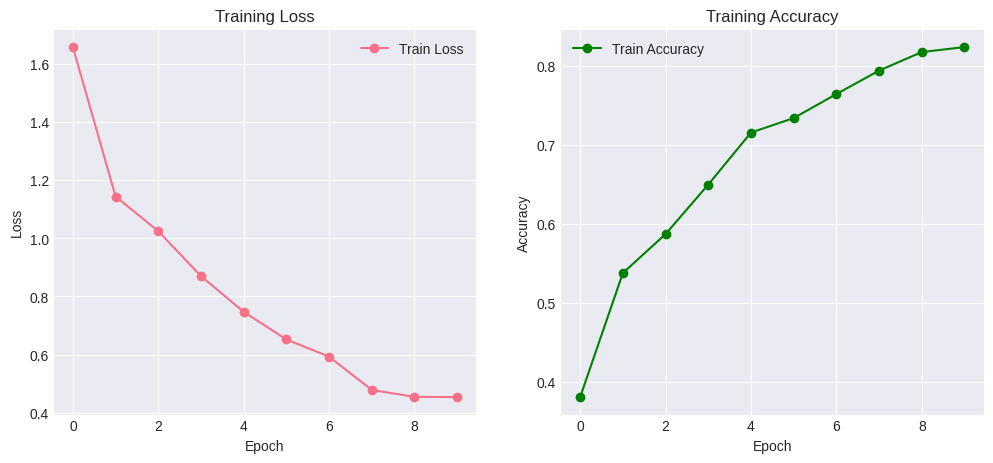

Running final evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

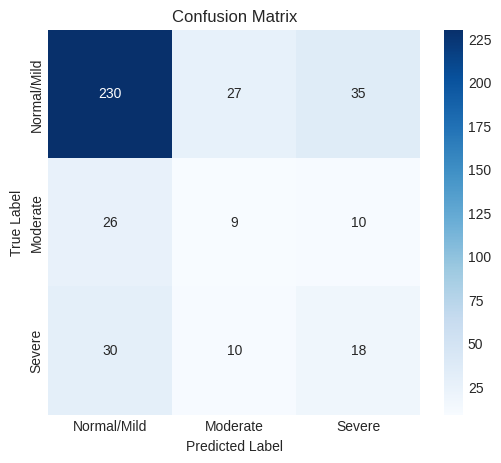


Classification Report:
              precision    recall  f1-score   support

 Normal/Mild       0.80      0.79      0.80       292
    Moderate       0.20      0.20      0.20        45
      Severe       0.29      0.31      0.30        58

    accuracy                           0.65       395
   macro avg       0.43      0.43      0.43       395
weighted avg       0.66      0.65      0.65       395



In [230]:


# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load Data
    base_path = BASE_PATH
    df = pd.read_csv(f'{base_path}/train.csv')

    # 2. Split Data
    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    # 3. Loaders
    train_dataset = RSYNASpineDataset(train_df, f'{base_path}/train_images', transform=get_transforms("train"))
    val_dataset = RSYNASpineDataset(val_df, f'{base_path}/train_images', transform=get_transforms("valid"))

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    # 4. Calculate Class Weights (Fix for Imbalance)
    target_col = 'spinal_canal_stenosis_l4_l5'
    class_counts = train_df[target_col].value_counts().sort_index()

    # Ensure order: Normal/Mild, Moderate, Severe
    counts = np.array([class_counts.get('Normal/Mild', 0),
                       class_counts.get('Moderate', 0),
                       class_counts.get('Severe', 0)])

    counts = np.maximum(counts, 1) # Avoid div by zero
    total_samples = sum(counts)
    weights = total_samples / (len(counts) * counts)
    class_weights = torch.FloatTensor(weights).to(CONFIG["device"])

    print(f"Using Class Weights: {class_weights.cpu().numpy()}")

    # 5. Initialize Model
    model = EfficientNetSpineModel(
    model_name=CONFIG["backbone"],
    num_classes=CONFIG["num_classes"],
    in_chans=CONFIG["n_slices"]
)
    model = model.to(CONFIG["device"])

    # --- LOSS & OPTIMIZER ---
    # Multi-label classification → BCEWithLogitsLoss recommended
    # For multi-class → use CrossEntropyLoss
    criterion = nn.CrossEntropyLoss(weight=class_weights) # or nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
    # 6. Training Loop
    history = {'train_loss': [], 'train_acc': []}
    print(f"Starting training on {CONFIG['device']} for {CONFIG['epochs']} epochs...")

    for epoch in range(CONFIG["epochs"]):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    # 7. Plotting
    print("Generating plots...")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Save plot to avoid javascript display errors
    plt.savefig('training_history.png')
    plt.show()

    # 8. Final Evaluation
    print("Running final evaluation...")
    true_labels, pred_labels = get_predictions(model, val_loader, CONFIG["device"])
    class_names = ['Normal/Mild', 'Moderate', 'Severe']

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

### RESNET MODEL

In [216]:
import torch
import torch.nn as nn
import timm

# --- RESNET MODEL ---
class ResNetSpineModel(nn.Module):
    def __init__(self, model_name="resnet50", num_classes=26, pretrained=True, in_chans=15):
        """
        model_name: string, timm resnet model name, e.g., "resnet18", "resnet50"
        num_classes: number of output labels
        pretrained: whether to use pretrained weights
        in_chans: number of input channels (15 for 5 slices * 3 channels)
        """
        super(ResNetSpineModel, self).__init__()

        # Create resnet backbone
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            in_chans=in_chans,
            num_classes=num_classes  # directly set output
        )

    def forward(self, x):
        return self.backbone(x)


Using Class Weights: [0.44229692 2.7413194  2.671743  ]
Starting training on cuda for 10 epochs...


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 1.7066 - Acc: 0.4032


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.2710 - Acc: 0.4911


...

Epoch 8/10 - Loss: 0.5127 - Acc: 0.7911


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.5061 - Acc: 0.8209


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.4738 - Acc: 0.8139
Generating plots...


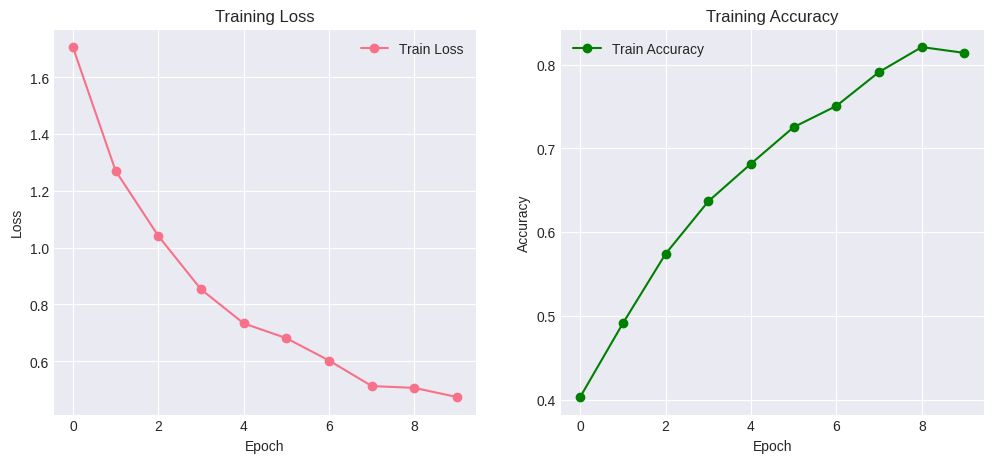

Running final evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

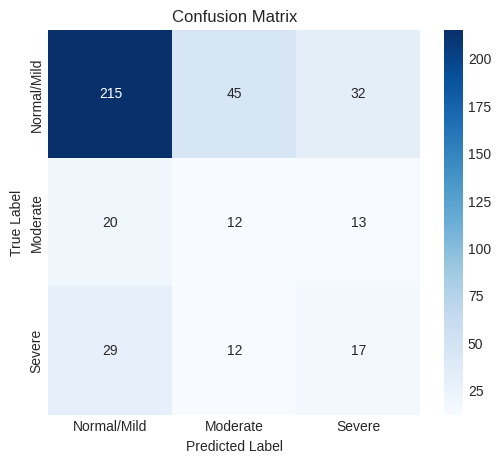


Classification Report:
              precision    recall  f1-score   support

 Normal/Mild       0.81      0.74      0.77       292
    Moderate       0.17      0.27      0.21        45
      Severe       0.27      0.29      0.28        58

    accuracy                           0.62       395
   macro avg       0.42      0.43      0.42       395
weighted avg       0.66      0.62      0.64       395



In [217]:


# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load Data
    base_path = BASE_PATH
    df = pd.read_csv(f'{base_path}/train.csv')

    # 2. Split Data
    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    # 3. Loaders
    train_dataset = RSYNASpineDataset(train_df, f'{base_path}/train_images', transform=get_transforms("train"))
    val_dataset = RSYNASpineDataset(val_df, f'{base_path}/train_images', transform=get_transforms("valid"))

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    # 4. Calculate Class Weights (Fix for Imbalance)
    target_col = 'spinal_canal_stenosis_l4_l5'
    class_counts = train_df[target_col].value_counts().sort_index()

    # Ensure order: Normal/Mild, Moderate, Severe
    counts = np.array([class_counts.get('Normal/Mild', 0),
                       class_counts.get('Moderate', 0),
                       class_counts.get('Severe', 0)])

    counts = np.maximum(counts, 1) # Avoid div by zero
    total_samples = sum(counts)
    weights = total_samples / (len(counts) * counts)
    class_weights = torch.FloatTensor(weights).to(CONFIG["device"])

    print(f"Using Class Weights: {class_weights.cpu().numpy()}")

    # 5. Initialize Model
    model = ResNetSpineModel(CONFIG["backbone"], CONFIG["num_classes"], in_chans=CONFIG["n_slices"])
    model = model.to(CONFIG["device"])

    # --- LOSS & OPTIMIZER ---
    # For multi-class classification (CrossEntropyLoss)
    # If you have multi-label (26 labels), use BCEWithLogitsLoss instead
    criterion = nn.CrossEntropyLoss(weight=class_weights)  # or BCEWithLogitsLoss for multi-label
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # 6. Training Loop
    history = {'train_loss': [], 'train_acc': []}
    print(f"Starting training on {CONFIG['device']} for {CONFIG['epochs']} epochs...")

    for epoch in range(CONFIG["epochs"]):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    # 7. Plotting
    print("Generating plots...")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Save plot to avoid javascript display errors
    plt.savefig('training_history.png')
    plt.show()

    # 8. Final Evaluation
    print("Running final evaluation...")
    true_labels, pred_labels = get_predictions(model, val_loader, CONFIG["device"])
    class_names = ['Normal/Mild', 'Moderate', 'Severe']

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

### SPINE MODEL

In [188]:
# --- MODEL ---
class SpineModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super(SpineModel, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, in_chans=CONFIG["n_slices"])
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


Using Class Weights: [0.44229692 2.7413194  2.671743  ]


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Starting training on cuda for 10 epochs...


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 1.0812 - Acc: 0.5810


...

Epoch 8/10 - Loss: 0.4536 - Acc: 0.8247


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.3965 - Acc: 0.8456


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.3511 - Acc: 0.8614
Generating plots...


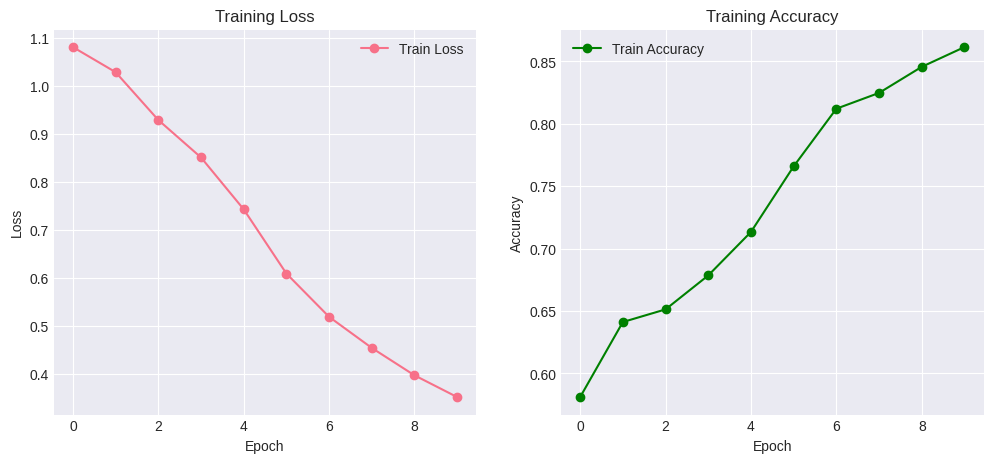

Running final evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

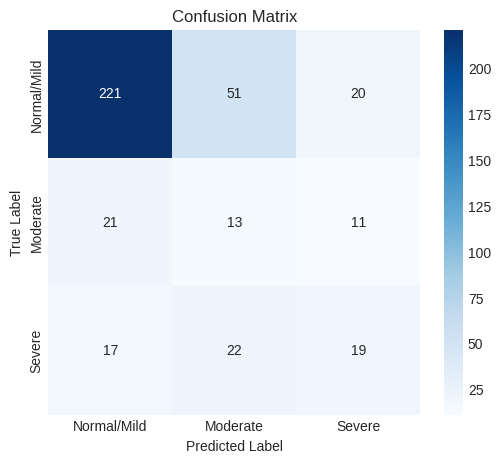


Classification Report:
              precision    recall  f1-score   support

 Normal/Mild       0.85      0.76      0.80       292
    Moderate       0.15      0.29      0.20        45
      Severe       0.38      0.33      0.35        58

    accuracy                           0.64       395
   macro avg       0.46      0.46      0.45       395
weighted avg       0.70      0.64      0.67       395



In [182]:

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load Data
    base_path = BASE_PATH
    df = pd.read_csv(f'{base_path}/train.csv')

    # 2. Split Data
    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    # 3. Loaders
    train_dataset = RSYNASpineDataset(train_df, f'{base_path}/train_images', transform=get_transforms("train"))
    val_dataset = RSYNASpineDataset(val_df, f'{base_path}/train_images', transform=get_transforms("valid"))

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    # 4. Calculate Class Weights (Fix for Imbalance)
    target_col = 'spinal_canal_stenosis_l4_l5'
    class_counts = train_df[target_col].value_counts().sort_index()

    # Ensure order: Normal/Mild, Moderate, Severe
    counts = np.array([class_counts.get('Normal/Mild', 0),
                       class_counts.get('Moderate', 0),
                       class_counts.get('Severe', 0)])

    counts = np.maximum(counts, 1) # Avoid div by zero
    total_samples = sum(counts)
    weights = total_samples / (len(counts) * counts)
    class_weights = torch.FloatTensor(weights).to(CONFIG["device"])

    print(f"Using Class Weights: {class_weights.cpu().numpy()}")

    # 5. Initialize Model
    model = SpineModel(CONFIG["backbone"], CONFIG["num_classes"]).to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=class_weights) # Apply weights
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # 6. Training Loop
    history = {'train_loss': [], 'train_acc': []}
    print(f"Starting training on {CONFIG['device']} for {CONFIG['epochs']} epochs...")

    for epoch in range(CONFIG["epochs"]):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    # 7. Plotting
    print("Generating plots...")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Save plot to avoid javascript display errors
    plt.savefig('training_history.png')
    plt.show()

    # 8. Final Evaluation
    print("Running final evaluation...")
    true_labels, pred_labels = get_predictions(model, val_loader, CONFIG["device"])
    class_names = ['Normal/Mild', 'Moderate', 'Severe']

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

### VIT MODEL

In [232]:
# --- VIT MODEL CLASS ---
class ViTSpineModel(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", num_classes=26, pretrained=True, in_chans=15):
        super(ViTSpineModel, self).__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            in_chans=in_chans,
            num_classes=num_classes  # directly set output layer
        )

    def forward(self, x):
        return self.backbone(x)


Using Class Weights: [0.44229692 2.7413194  2.671743  ]
Starting training on cuda for 10 epochs...


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 1.6897 - Acc: 0.4057


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.2186 - Acc: 0.5247


...

Epoch 8/10 - Loss: 0.5329 - Acc: 0.7981


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.4770 - Acc: 0.8203


Training:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.4238 - Acc: 0.8272
Generating plots...


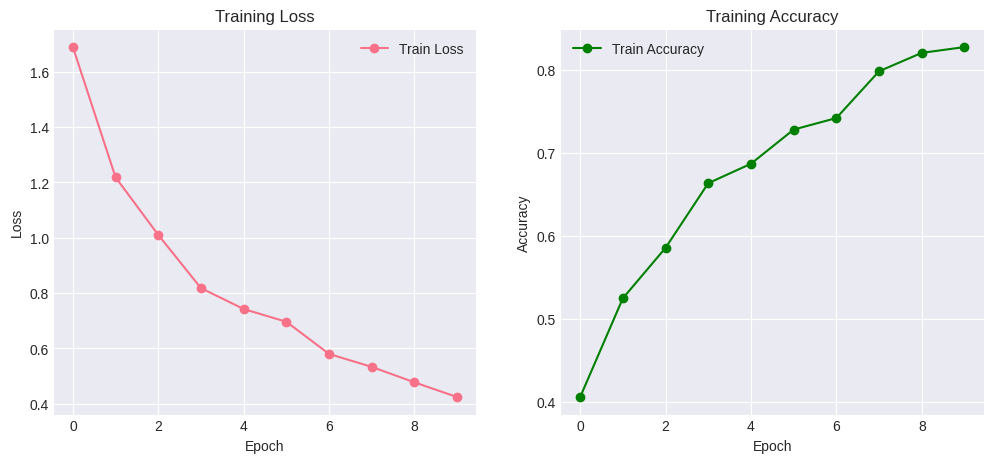

Running final evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

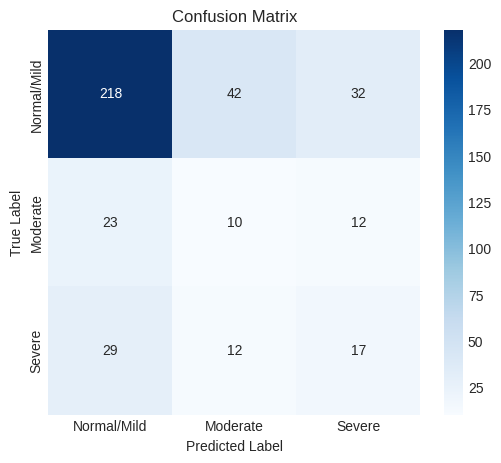


Classification Report:
              precision    recall  f1-score   support

 Normal/Mild       0.81      0.75      0.78       292
    Moderate       0.16      0.22      0.18        45
      Severe       0.28      0.29      0.29        58

    accuracy                           0.62       395
   macro avg       0.41      0.42      0.42       395
weighted avg       0.66      0.62      0.64       395



In [233]:

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load Data
    base_path = BASE_PATH
    df = pd.read_csv(f'{base_path}/train.csv')

    # 2. Split Data
    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    # 3. Loaders
    train_dataset = RSYNASpineDataset(train_df, f'{base_path}/train_images', transform=get_transforms("train"))
    val_dataset = RSYNASpineDataset(val_df, f'{base_path}/train_images', transform=get_transforms("valid"))

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    # 4. Calculate Class Weights (Fix for Imbalance)
    target_col = 'spinal_canal_stenosis_l4_l5'
    class_counts = train_df[target_col].value_counts().sort_index()

    # Ensure order: Normal/Mild, Moderate, Severe
    counts = np.array([class_counts.get('Normal/Mild', 0),
                       class_counts.get('Moderate', 0),
                       class_counts.get('Severe', 0)])

    counts = np.maximum(counts, 1) # Avoid div by zero
    total_samples = sum(counts)
    weights = total_samples / (len(counts) * counts)
    class_weights = torch.FloatTensor(weights).to(CONFIG["device"])

    print(f"Using Class Weights: {class_weights.cpu().numpy()}")

    # 5. Initialize Model
    model = ViTSpineModel(
    model_name=CONFIG["backbone"],
    num_classes=CONFIG["num_classes"],
    in_chans=CONFIG["n_slices"]
    )
    model = model.to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=class_weights) # Apply weights
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # 6. Training Loop
    history = {'train_loss': [], 'train_acc': []}
    print(f"Starting training on {CONFIG['device']} for {CONFIG['epochs']} epochs...")

    for epoch in range(CONFIG["epochs"]):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    # 7. Plotting
    print("Generating plots...")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Save plot to avoid javascript display errors
    plt.savefig('training_history.png')
    plt.show()

    # 8. Final Evaluation
    print("Running final evaluation...")
    true_labels, pred_labels = get_predictions(model, val_loader, CONFIG["device"])
    class_names = ['Normal/Mild', 'Moderate', 'Severe']

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))